Approach:
- explore rating distributions
     - plot rating distributions
     - look at review text
     - check out metadata

- split training into train vs. validation
    - like hold user's last interactions from `train.csv` for validation

- what makes a good user profile?
    - user who loves puzzles will have review mentioning puzzle, brain teaser, etc
    

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [10]:
metadata = pd.read_csv("item_metadata.csv")
test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")

In [11]:
metadata

,item_id,title,description,features,categories,main_category,store,price,average_rating
0,i_5165,Mahjong 2015,Mahjong 2015 is a free solitaire matching game...,Mahjong 2015 is a free solitaire matching game...,NaN,Appstore for Android,sophiathach,0.00,3.1
1,i_7178,RoverCraft Race Your Space Car,Play The World Famous Car Crafting Runner with...,14 different planets from the galaxy to race o...,NaN,Appstore for Android,Mobirate,0.00,3.9
2,i_4289,Just Escape,"Just Escape, whether it's a medieval castle or...",Escape from rooms deep in a medieval castle or...,NaN,Appstore for Android,Inertia Game Studios,0.00,3.5
3,i_4772,TurboTax Deluxe 2014 Fed + State + Fed Efile T...,Tax Software that helps you get your taxes don...,This product is backed by Intuit’s 60 Day Mone...,"Software, Intuit, All Intuit",Software,Intuit,NaN,4.4
4,i_4232,How to Draw: Frozen,Frozen Characters drawing lessons are grouped ...,Free to use! Portable so you can learn to draw...,NaN,Appstore for Android,DrawMate,0.00,3.7
...,...,...,...,...,...,...,...,...,...
8676,i_2903,Office Suite,Office Suite is the best alternative to other ...,Includes a complete word processor to help wit...,"Software, Children's",Software,Encore,NaN,2.7
8677,i_0638,Corel Photo and Video Pro X4 Ultimate Bundle [...,Product Description With our best photo- and v...,Ultimate bundle combines powerful photo- and v...,"Software, Corel, All Corel",NaN,Corel,99.99,3.1
8678,i_3518,Corel WinZip 18 [Old Version],Unzip all major formats Protect your privacy V...,The world's #1 compression software Privacy pr...,"Software, Corel, All Corel",Software,Corel,NaN,3.2
8679,i_3096,Quicken Rental Property Manager 2014 [OLD VERS...,From the Manufacturer Intuit Quicken Rental Pr...,Organizes your personal and rental property fi...,"Software, Accounting & Finance, Personal Finan...",Software,Intuit,NaN,3.1


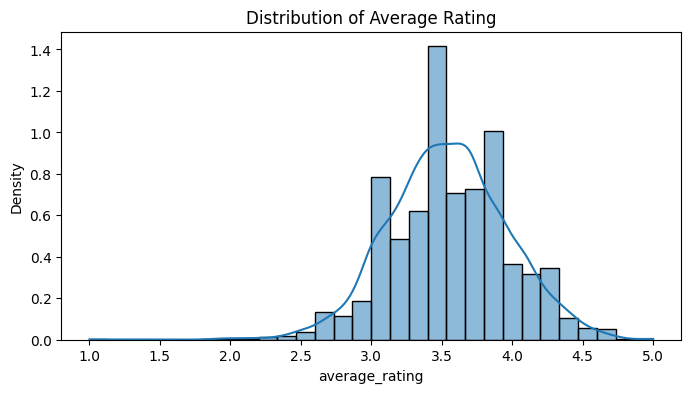

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(metadata["average_rating"], kde=True, stat="density", bins=30)
plt.xlabel("average_rating")
plt.ylabel("Density")
plt.title("Distribution of Average Rating")
plt.show()

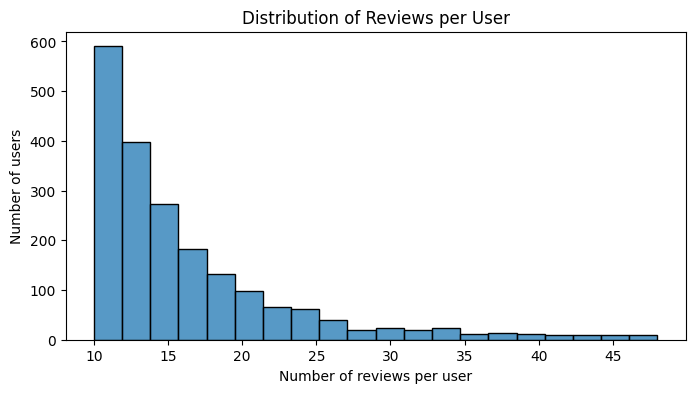

In [27]:
interactions_per_user = train.groupby("user_id").count()["rating"]

plt.figure(figsize=(8, 4))
sns.histplot(interactions_per_user, bins = 20)
plt.xlabel("Number of reviews per user")
plt.ylabel("Number of users")
plt.title("Distribution of Reviews per User")
plt.show()

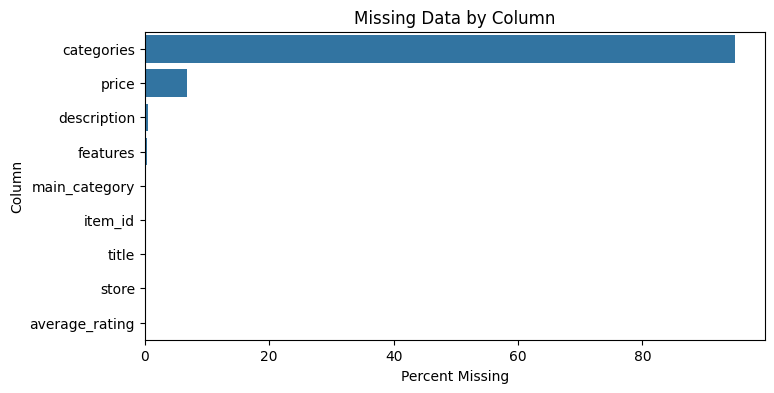

In [34]:
missing = (
    metadata.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "column"})
)

plt.figure(figsize=(8, 4))
sns.barplot(data=missing, x="missing_pct", y="column")
plt.xlabel("Percent Missing")
plt.ylabel("Column")
plt.title("Missing Data by Column")
plt.show()


In [74]:
text_cols = ["title", "features", "description"]

summary = []
for col in text_cols:
    s = metadata[col].fillna("").astype(str).str.strip()
    word_count = s.str.split().str.len()
    char_count = s.str.len()

    summary.append({
        "column": col,
        "missing_pct": metadata[col].isna().mean() * 100,
        "word_stddev": word_count.std(),
        "char_stddev": char_count.std(),
        "empty_pct": (s == "").mean() * 100,
        "duplicate_pct": s.duplicated().mean() * 100,
        "avg_words": word_count.mean(),
        "median_words": word_count.median(),
        "p90_words": word_count.quantile(0.9),
        "avg_chars": char_count.mean(),
        "median_chars": char_count.median(),
    })

summary_df = pd.DataFrame(summary)
summary_df.T

,0,1,2
column,title,features,description
missing_pct,0.0,0.426218,0.483815
word_stddev,4.815061,43.85801,346.946942
char_stddev,28.731845,264.290027,2217.315266
empty_pct,0.0,0.426218,0.483815
duplicate_pct,1.693353,5.759705,2.004377
avg_words,5.067734,48.101486,223.016818
median_words,4.0,36.0,158.0
p90_words,10.0,96.0,440.0
avg_chars,30.201359,297.125101,1392.179242


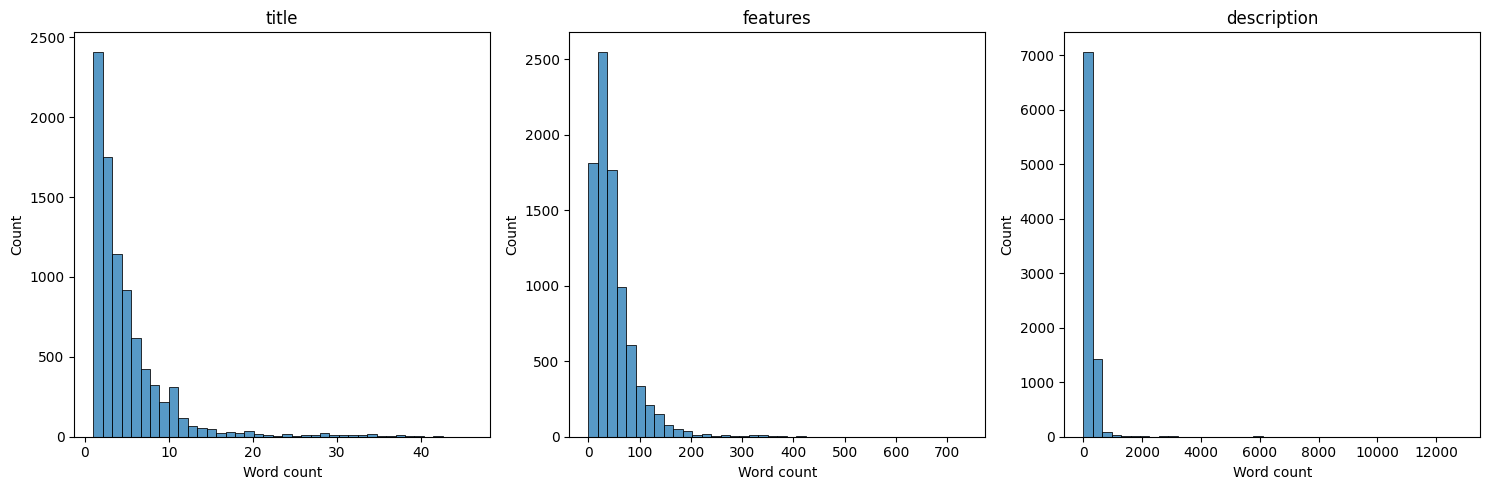

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, text_cols):
    s = metadata[col].fillna("").astype(str).str.strip()
    word_count = s.str.split().str.len()
    sns.histplot(word_count, bins=40, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Word count")

plt.tight_layout()
plt.show()

In [69]:
for col in text_cols:
    s = metadata[col].fillna("").astype(str).str.strip()
    print(f"\n--- {col} ---")
    print("Missing %:", metadata[col].isna().mean())
    print("Empty %:", (s == "").mean())
    print("Duplicate %:", s.duplicated().mean())
    print("Very short % (<5 words):", (s.str.split().str.len() < 5).mean())


--- title ---
Missing %: 0.0
Empty %: 0.0
Duplicate %: 0.016933533003110242
Very short % (<5 words): 0.6105287409284644

--- features ---
Missing %: 0.004262181776293054
Empty %: 0.004262181776293054
Duplicate %: 0.057597051030987216
Very short % (<5 words): 0.019122220942287754

--- description ---
Missing %: 0.0048381522866029255
Empty %: 0.0048381522866029255
Duplicate %: 0.02004377375878355
Very short % (<5 words): 0.00806358714433821


In [70]:
for col in text_cols:
    s = metadata[col].fillna("").astype(str).str.strip()
    wc = s.str.split().str.len()
    tmp = pd.DataFrame({col: s, "words": wc})

    print(f"\nShortest {col}:")
    print(tmp.sort_values("words").head(5)[[col, "words"]].to_string(index=False))

    print(f"\nLongest {col}:")
    print(tmp.sort_values("words", ascending=False).head(5)[[col, "words"]].to_string(index=False))



Shortest title:
    title  words
   YachtC      1
  Hangman      1
Bookshelf      1
     Romi      1
     WMAL      1

Longest title:
                                                                                                                                                                                                                                                     title  words
  Candy Soda Pop Diamond Land Edition 2 - FREE PUZZLE GAME for Kindle Fire HD! Download match-3 mania app & you can play offline whenever you want, no internet needed, no wifi required. The best candies charm blitz game ever for kids is new for 2015!     46
   Off-Road Extreme Bicycle Freestyle Stunt Mania 2018 : Free Racing Games For Kids boy blast mayhem ride riding trails tricks moter race skate 2 bmx 3d run rental car boat beach city drag hero jump grind pro trial driver dummy fever star tracks fest     44
   YouIpCams: Amazon Fire TV App - Turn Your Exiting Cheap IP Camera Into an End-To-End Enc